## Desafio D — Sistema de Registro de Preços

### Problema

Quais características diferenciam contratações realizadas com e sem Sistema de Registro de Preços?

### Possíveis perguntas

- O SRP é mais frequente em determinados tipos de contratação?
- Existem diferenças nos valores das contratações?
- Determinados órgãos utilizam SRP proporcionalmente mais do que outros?

### Variável de interesse

Quando disponível:

```text
srp
```

### Possíveis análises

- proporções;
- tabelas cruzadas;
- comparação de valores;
- teste qui-quadrado.


documentação API: https://dadosabertos.compras.gov.br/swagger-ui/index.html


## Instalação e importação das bibliotecas utilizadas

In [65]:
#!pip install requests pandas matplotlib -q
#!pip install pyarrow
#!pip install scipy

In [69]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import chi2_contingency, mannwhitneyu

## Pegando a base do ENDPOINT para a consulta da API

In [3]:
BASE_URL = "https://dadosabertos.compras.gov.br"

ENDPOINT_CONTRATACOES = "/modulo-contratacoes/1_consultarContratacoes_PNCP_14133"

url = BASE_URL + ENDPOINT_CONTRATACOES

print(url)

https://dadosabertos.compras.gov.br/modulo-contratacoes/1_consultarContratacoes_PNCP_14133


## Criando função para extrair os registros e dados da API

In [ ]:
def extrair_registros(json_resposta):

    if isinstance(json_resposta, list): # Se a reposta ja for uma lista, ele apenas retorna ela
        return json_resposta

    if not isinstance(json_resposta, dict):  # Se a reposta nao for uma lista e nem um dicionario, ele apenas retorna uma lista vazia para reagir a respostas inesperadas
        return []

    for chave in ["resultado", "resultados", "data", "content"]: # Checa se no dicionario as  inormações vieram por esse nome
        if chave in json_resposta and isinstance(json_resposta[chave], list):
            return json_resposta[chave] # Se veio essas chaves e se o valor associado a ele tambem veio, retorna os dados

    return [] # Se ele não achar nada, retorna a lista vazia



# Coleta de Dados

## Escolha dos dados
A seguir serão coletados os dados referente ao ano de 2024 e 2025, nas modalidades de pregão-eletronico e dispensa, com o objetivo de analisar o SRP e fazer uma analise de dados 

## Coletando dados de 2024

In [5]:
modalidades = [5, 6] # Pega principais modalidades
todos_registros = []

In [6]:
for modalidade in modalidades:
    pagina = 1
    total_modalidade = 0

    while True:
        params = {
            "pagina": pagina,
            "tamanhoPagina": 500,
            "dataPublicacaoPncpInicial": "2024-01-01",
            "dataPublicacaoPncpFinal": "2024-12-31",
            "codigoModalidade": modalidade
        }

        resposta = requests.get(url, params=params, timeout=60)

        if resposta.status_code == 429:
            espera = 5
            print(f"Modalidade {modalidade}, página {pagina}: 429, aguardando {espera}s e tentando de novo...")
            time.sleep(espera)
            continue  # tenta a mesma página de novo, sem avançar

        if resposta.status_code != 200:
            print(f"Modalidade {modalidade}, página {pagina}: erro {resposta.status_code}")
            break

        dados = resposta.json()
        registros = extrair_registros(dados)

        if not registros:
            break

        todos_registros.extend(registros)
        total_modalidade += len(registros)

        if len(registros) < 500:
            break

        pagina += 1
        time.sleep(0.2)  # pausa maior entre páginas

    print(f"Modalidade {modalidade}: {total_modalidade} registros coletados.")
    time.sleep(3)  # pausa entre modalidades, para o servidor "esfriar"

Modalidade 5: 104142 registros coletados.
Modalidade 6: 133930 registros coletados.


In [ ]:
df_24 = pd.json_normalize(todos_registros)
df_24.head()

,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,tipoInstrumentoConvocatorioNome,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida
0,17013105000172023,00394460000141-1-001631/2023,2023,1631,00394460000141,NaN,45178,MINISTERIO DA FAZENDA,NaN,F,...,Edital,Aberto-Fechado,614963.83,343793.5,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T09:00:00,2024-01-22T10:00:00,False
1,41300105000262023,02030715000112-1-000226/2023,2023,226,02030715000112,NaN,89804,AGENCIA NACIONAL DE TELECOMUNICACOES,NaN,F,...,Edital,Aberto-Fechado,404.74,NaN,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T08:00:00,2024-01-17T10:00:00,False
2,15812605000492023,10729992000146-1-000127/2023,2023,127,10729992000146,NaN,7087,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Edital,Aberto-Fechado,105000.00,105000.0,2024-01-02T07:00:05,2024-01-15T07:07:29,2024-01-02T07:00:05,2024-01-02T08:00:00,2024-01-16T10:00:00,False
3,12006005000362023,00394429000100-1-002260/2023,2023,2260,00394429000100,NaN,43849,COMANDO DA AERONAUTICA,NaN,F,...,Edital,Aberto,286011.82,270000.0,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T08:00:00,2024-01-17T09:00:00,False
4,51017805000112023,29979036000140-1-000084/2023,2023,84,29979036000140,NaN,26661,INSTITUTO NACIONAL DO SEGURO SOCIAL,NaN,F,...,Edital,Aberto,232490.96,NaN,2024-01-02T07:00:09,2024-02-28T07:09:02,2024-01-02T07:00:09,2024-01-02T09:00:00,2024-01-16T09:00:00,False


In [ ]:

df_24["ano"] = 2024 # Adiciona a coluna "ano" a fim de saber o ano da contribuição

df_24.to_parquet("raw_completo_2024.parquet", index=False) # Salva parquet de 2024


if 'srp' in df_24.columns: # Verifica se o SRP veio na tabela
    print("\nValores brutos encontrados na coluna SRP:")
    print(df_24['srp'].value_counts(dropna=False)) # Vê quantos valores diferentes vieram para verificar valores nulos

    # Cria uma tabela auxiliar com os dados de 2024
    df_24_com_srp = df_24[df_24['srp'] == True] 
    df_24_sem_srp = df_24[df_24['srp'] == False]

    # Mostra quantos valores vieram em cada um
    print(f"\n Total COM SRP: {len(df_24_com_srp)}")
    print(f" Total SEM SRP: {len(df_24_sem_srp)}")



Valores brutos encontrados na coluna SRP:
srp
False    194102
True      43970
Name: count, dtype: int64

 Total COM SRP: 43970
 Total SEM SRP: 194102


In [ ]:
# Mostra os dataframes criados
print("\nDataFrame com SRP:")
display(df_24_com_srp.head())
print("\nDataFrame sem SRP:")
display(df_24_sem_srp.head())


DataFrame com SRP:


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
0,17013105000172023,00394460000141-1-001631/2023,2023,1631,00394460000141,NaN,45178,MINISTERIO DA FAZENDA,NaN,F,...,Aberto-Fechado,614963.83,343793.50,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T09:00:00,2024-01-22T10:00:00,False,2024
7,92804805900012024,88830609000139-1-000001/2024,2024,1,88830609000139,NaN,41243,MUNICIPIO DE CAXIAS DO SUL,NaN,M,...,Aberto,68469.70,27300.60,2024-01-02T07:00:16,2024-01-02T07:00:16,2024-01-02T07:00:16,2024-01-02T08:00:00,2024-01-16T08:30:00,False,2024
9,15590105000962023,15126437000143-1-003231/2023,2023,3231,15126437000143,NaN,95159,EMPRESA BRASILEIRA DE SERVIÇOS HOSPITALARES,NaN,F,...,Aberto-Fechado,137987.47,103025.62,2024-01-02T07:00:20,2024-01-02T07:00:20,2024-01-02T07:00:20,2024-01-02T08:00:00,2024-01-12T09:00:00,False,2024
11,15812605000352023,10729992000146-1-000128/2023,2023,128,10729992000146,NaN,7087,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Aberto,13225.77,1600.00,2024-01-02T07:00:23,2024-01-02T07:00:23,2024-01-02T07:00:23,2024-01-02T08:00:00,2024-01-22T10:00:00,False,2024
12,16039905000432023,00394452000103-1-014522/2023,2023,14522,00394452000103,NaN,44611,COMANDO DO EXERCITO,NaN,F,...,Aberto-Fechado,6389632.82,1145924.50,2024-01-02T07:00:24,2024-01-05T07:04:20,2024-01-02T07:00:24,2024-01-05T08:00:00,2024-01-17T09:00:00,False,2024



DataFrame sem SRP:


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
1,41300105000262023,02030715000112-1-000226/2023,2023,226,02030715000112,NaN,89804,AGENCIA NACIONAL DE TELECOMUNICACOES,NaN,F,...,Aberto-Fechado,404.74,NaN,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T08:00:00,2024-01-17T10:00:00,False,2024
2,15812605000492023,10729992000146-1-000127/2023,2023,127,10729992000146,NaN,7087,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Aberto-Fechado,105000.00,105000.0,2024-01-02T07:00:05,2024-01-15T07:07:29,2024-01-02T07:00:05,2024-01-02T08:00:00,2024-01-16T10:00:00,False,2024
3,12006005000362023,00394429000100-1-002260/2023,2023,2260,00394429000100,NaN,43849,COMANDO DA AERONAUTICA,NaN,F,...,Aberto,286011.82,270000.0,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T08:00:00,2024-01-17T09:00:00,False,2024
4,51017805000112023,29979036000140-1-000084/2023,2023,84,29979036000140,NaN,26661,INSTITUTO NACIONAL DO SEGURO SOCIAL,NaN,F,...,Aberto,232490.96,NaN,2024-01-02T07:00:09,2024-02-28T07:09:02,2024-01-02T07:00:09,2024-01-02T09:00:00,2024-01-16T09:00:00,False,2024
5,92668605000222023,04801221000110-1-000444/2023,2023,444,04801221000110,NaN,53800,TRIBUNAL DE CONTAS DO ESTADO DE RONDONIA,NaN,E,...,Aberto,99975.00,95466.0,2024-01-02T07:00:10,2024-01-02T07:00:10,2024-01-02T07:00:10,2024-01-02T08:00:00,2024-01-16T10:00:00,False,2024


In [ ]:
# Dataframe utiliando GroupBy agregando com nunique (únicos) e count (total de registros)
df_qnt_modalidade_orgao_24 = df_24.groupby('srp').agg(
    qtd_modalidades=('modalidadeNome', 'nunique'),
    qtd_orgaos=('orgaoEntidadeRazaoSocial', 'nunique'),
    total_registros=('numeroCompra', 'count')
)

df_qnt_modalidade_orgao_24.index = ['Sem SRP', 'Com SRP'] # Renomeia os índices para facilitar a leitura no relatório

display(df_qnt_modalidade_orgao_24)

,qtd_modalidades,qtd_orgaos,total_registros
Sem SRP,3,2463,194102
Com SRP,3,1423,43970


# Pegando dados 2025

In [11]:
modalidades = [5, 6] # Pega principais modalidades
todos_registros = []

In [12]:
for modalidade in modalidades:
    pagina = 1
    total_modalidade = 0

    while True:
        params = {
            "pagina": pagina,
            "tamanhoPagina": 500,
            "dataPublicacaoPncpInicial": "2025-01-01",
            "dataPublicacaoPncpFinal": "2025-12-31",
            "codigoModalidade": modalidade,
        }

        resposta = requests.get(url, params=params, timeout=60)

        if resposta.status_code == 429:
            espera = 5
            print(f"Modalidade {modalidade}, página {pagina}: 429, aguardando {espera}s e tentando de novo...")
            time.sleep(espera)
            continue  # tenta a mesma página de novo, sem avançar

        if resposta.status_code != 200:
            print(f"Modalidade {modalidade}, página {pagina}: erro {resposta.status_code}")
            break

        dados = resposta.json()
        registros = extrair_registros(dados)

        if not registros:
            break

        todos_registros.extend(registros)
        total_modalidade += len(registros)

        if len(registros) < 500:
            break

        pagina += 1
        time.sleep(0.2)  # pausa maior entre páginas

    print(f"Modalidade {modalidade}: {total_modalidade} registros coletados.")
    time.sleep(3)  # pausa entre modalidades, para o servidor "esfriar"

Modalidade 5: 114824 registros coletados.
Modalidade 6: 131369 registros coletados.


In [ ]:
df_25 = pd.json_normalize(todos_registros)
df_25.head()

,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,tipoInstrumentoConvocatorioNome,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida
0,92647305900242024,06272868000127-1-000056/2024,2024,56,06272868000127,NaN,56302,CONSELHO REGIONAL DE ENFERMAGEM COREN MA,NaN,F,...,Edital,Aberto-Fechado,400000.00,NaN,2025-01-02T09:03:34,2025-01-02T09:03:34,2025-01-02T09:03:34,2025-01-02T08:00:00,2025-01-16T09:00:00,False
1,92647305900252024,06272868000127-1-000057/2024,2024,57,06272868000127,NaN,56302,CONSELHO REGIONAL DE ENFERMAGEM COREN MA,NaN,F,...,Edital,Aberto-Fechado,250782.10,151826.000,2025-01-02T09:03:38,2025-01-02T09:03:38,2025-01-02T09:03:38,2025-01-02T08:00:00,2025-01-14T09:00:00,False
2,38910305900162024,21947619000188-1-000068/2024,2024,68,21947619000188,NaN,21599,CONSELHO REGIONAL DE FISIOTERAPIA E TERAPIA OC...,NaN,F,...,Edital,Aberto-Fechado,868719.38,NaN,2025-01-02T09:03:41,2025-01-02T09:03:41,2025-01-02T09:03:41,2025-01-02T09:00:00,2025-01-17T09:00:00,False
3,94300105913862024,07954480000179-1-023839/2024,2024,23839,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Edital,Aberto-Fechado,11147211.58,6619438.535,2025-01-02T09:03:47,2025-05-09T08:13:51,2025-01-02T09:03:47,2025-04-25T08:00:00,2025-05-15T09:00:00,False
4,38918505900112024,00119784000171-1-000036/2024,2024,36,00119784000171,NaN,43167,CONSELHO FEDERAL DE MEDICINA VETERINARIA,NaN,F,...,Edital,Aberto,4612985.04,3718205.520,2025-01-02T09:03:51,2025-09-22T07:36:06,2025-01-02T09:03:51,2025-09-22T08:00:00,2025-10-07T10:00:00,False


In [ ]:
df_25["ano"] = 2025 # Adiciona a coluna "ano" a fim de saber o ano da contribuição

df_25.to_parquet("raw_completo_2025.parquet", index=False) # Salva parquet de 2025


if 'srp' in df_25.columns: # Verifica se o SRP veio na tabela
    
    print("\nValores brutos encontrados na coluna SRP:")
    print(df_25['srp'].value_counts(dropna=False))  # Vê quantos valores diferentes vieram para verificar valores nulos


    # Cria uma tabela auxiliar com os dados de 2025
    df_25_com_srp = df_25[df_25['srp'] == True]
    df_25_sem_srp = df_25[df_25['srp'] == False]

    # Mostra quantos valores vieram em cada um
    print(f"\n Total COM SRP: {len(df_25_com_srp)}")
    print(f" Total SEM SRP: {len(df_25_sem_srp)}")


Valores brutos encontrados na coluna SRP:
srp
False    193987
True      52206
Name: count, dtype: int64

 Total COM SRP: 52206
 Total SEM SRP: 193987


In [15]:
print("\nDataFrame com SRP:")
display(df_25_com_srp.head())
print("\nDataFrame sem SRP:")
display(df_25_sem_srp.head())


DataFrame com SRP:


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
5,94300105914952024,07954480000179-1-023841/2024,2024,23841,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Aberto-Fechado,138742.18,89250.00,2025-01-02T09:03:57,2025-01-02T09:03:57,2025-01-02T09:03:57,2025-01-03T08:00:00,2025-01-15T14:30:00,False,2025
7,94300105913952024,07954480000179-1-023842/2024,2024,23842,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Aberto-Fechado,759632.82,551284.00,2025-01-02T09:04:04,2025-01-02T09:04:04,2025-01-02T09:04:04,2025-01-03T08:00:00,2025-01-15T14:30:00,False,2025
8,94300105910162024,07954480000179-1-023843/2024,2024,23843,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Aberto-Fechado,55242.57,37068.54,2025-01-02T09:04:07,2025-01-02T09:04:07,2025-01-02T09:04:07,2025-01-03T08:00:00,2025-01-15T09:00:00,False,2025
10,98748705900602024,75972760000160-1-000185/2024,2024,185,75972760000160,NaN,84922,MUNICIPIO DE CAPANEMA,NaN,M,...,Aberto,302156.25,206660.50,2025-01-02T09:04:14,2025-01-17T07:48:19,2025-01-02T09:04:14,2025-01-02T08:00:00,2025-01-21T08:30:00,False,2025
14,42512805900152024,02973240000106-1-000038/2024,2024,38,02973240000106,NaN,51122,ESTADO DO MARANHAO - SECRETARIA DE ESTADO DA S...,NaN,E,...,Aberto-Fechado,4425190.08,2782461.00,2025-01-02T09:04:26,2025-01-02T09:04:26,2025-01-02T09:04:26,2025-01-02T08:00:00,2025-01-15T09:00:00,False,2025



DataFrame sem SRP:


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
0,92647305900242024,06272868000127-1-000056/2024,2024,56,06272868000127,NaN,56302,CONSELHO REGIONAL DE ENFERMAGEM COREN MA,NaN,F,...,Aberto-Fechado,400000.00,NaN,2025-01-02T09:03:34,2025-01-02T09:03:34,2025-01-02T09:03:34,2025-01-02T08:00:00,2025-01-16T09:00:00,False,2025
1,92647305900252024,06272868000127-1-000057/2024,2024,57,06272868000127,NaN,56302,CONSELHO REGIONAL DE ENFERMAGEM COREN MA,NaN,F,...,Aberto-Fechado,250782.10,151826.000,2025-01-02T09:03:38,2025-01-02T09:03:38,2025-01-02T09:03:38,2025-01-02T08:00:00,2025-01-14T09:00:00,False,2025
2,38910305900162024,21947619000188-1-000068/2024,2024,68,21947619000188,NaN,21599,CONSELHO REGIONAL DE FISIOTERAPIA E TERAPIA OC...,NaN,F,...,Aberto-Fechado,868719.38,NaN,2025-01-02T09:03:41,2025-01-02T09:03:41,2025-01-02T09:03:41,2025-01-02T09:00:00,2025-01-17T09:00:00,False,2025
3,94300105913862024,07954480000179-1-023839/2024,2024,23839,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Aberto-Fechado,11147211.58,6619438.535,2025-01-02T09:03:47,2025-05-09T08:13:51,2025-01-02T09:03:47,2025-04-25T08:00:00,2025-05-15T09:00:00,False,2025
4,38918505900112024,00119784000171-1-000036/2024,2024,36,00119784000171,NaN,43167,CONSELHO FEDERAL DE MEDICINA VETERINARIA,NaN,F,...,Aberto,4612985.04,3718205.520,2025-01-02T09:03:51,2025-09-22T07:36:06,2025-01-02T09:03:51,2025-09-22T08:00:00,2025-10-07T10:00:00,False,2025


In [ ]:
# GroupBy agregando com nunique (únicos) e count (total de registros)
df_qnt_modalidade_orgao_25 = df_25.groupby('srp').agg(
    qtd_modalidades=('modalidadeNome', 'nunique'),
    qtd_orgaos=('orgaoEntidadeRazaoSocial', 'nunique'),
    total_registros=('numeroCompra', 'count')
)

df_qnt_modalidade_orgao_25.index = ['Sem SRP', 'Com SRP'] # Renomeia os índices para facilitar a leitura no relatório

display(df_qnt_modalidade_orgao_25)

,qtd_modalidades,qtd_orgaos,total_registros
Sem SRP,3,2871,193987
Com SRP,3,1646,52206


# Comparação 2024 X 2025

## Comparação das tabelas auxiliares 

In [53]:
display(df_qnt_modalidade_orgao_24)
display(df_qnt_modalidade_orgao_25)

,qtd_modalidades,qtd_orgaos,total_registros
Sem SRP,3,2463,194102
Com SRP,3,1423,43970


,qtd_modalidades,qtd_orgaos,total_registros
Sem SRP,3,2871,193987
Com SRP,3,1646,52206


### Gera um dataframe final com a junção dos dados de 2024 e 2025

In [54]:
df_total = pd.concat([df_24, df_25], ignore_index=True)
df_total

,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
0,17013105000172023,00394460000141-1-001631/2023,2023,1631,00394460000141,NaN,45178,MINISTERIO DA FAZENDA,NaN,F,...,Aberto-Fechado,614963.83,343793.50,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T09:00:00,2024-01-22T10:00:00,False,2024
1,41300105000262023,02030715000112-1-000226/2023,2023,226,02030715000112,NaN,89804,AGENCIA NACIONAL DE TELECOMUNICACOES,NaN,F,...,Aberto-Fechado,404.74,NaN,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T08:00:00,2024-01-17T10:00:00,False,2024
2,15812605000492023,10729992000146-1-000127/2023,2023,127,10729992000146,NaN,7087,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Aberto-Fechado,105000.00,105000.00,2024-01-02T07:00:05,2024-01-15T07:07:29,2024-01-02T07:00:05,2024-01-02T08:00:00,2024-01-16T10:00:00,False,2024
3,12006005000362023,00394429000100-1-002260/2023,2023,2260,00394429000100,NaN,43849,COMANDO DA AERONAUTICA,NaN,F,...,Aberto,286011.82,270000.00,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T08:00:00,2024-01-17T09:00:00,False,2024
4,51017805000112023,29979036000140-1-000084/2023,2023,84,29979036000140,NaN,26661,INSTITUTO NACIONAL DO SEGURO SOCIAL,NaN,F,...,Aberto,232490.96,NaN,2024-01-02T07:00:09,2024-02-28T07:09:02,2024-01-02T07:00:09,2024-01-02T09:00:00,2024-01-16T09:00:00,False,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484260,16013706000462025,00394452000103-1-024933/2025,2025,24933,00394452000103,NaN,44611,COMANDO DO EXERCITO,NaN,F,...,Não se aplica,2040.48,2040.48,2025-12-30T20:15:02,2025-12-30T20:15:02,2025-12-30T20:15:02,NaN,NaN,False,2025
484261,13500206000312025,00348003002245-1-000544/2025,2025,544,00348003002245,NaN,97892,EMPRESA BRASILEIRA DE PESQUISA AGROPECUARIA,NaN,N,...,Não se aplica,157970.43,157970.43,2025-12-30T20:19:40,2025-12-30T20:19:40,2025-12-30T20:19:40,NaN,NaN,False,2025
484262,15814306001252025,10791831000182-1-000053/2025,2025,53,10791831000182,NaN,60822,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Não se aplica,1522362.00,1522362.00,2025-12-30T21:22:29,2025-12-30T21:22:29,2025-12-30T21:22:29,NaN,NaN,False,2025
484263,15814306001262025,10791831000182-1-000054/2025,2025,54,10791831000182,NaN,60822,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Não se aplica,252900.00,252900.00,2025-12-30T21:35:41,2025-12-30T21:35:41,2025-12-30T21:35:41,NaN,NaN,False,2025


# Checamos duplicatas

In [55]:
# >>> AQUI ENTRA A CHECAGEM DE DUPLICATAS <
chave_dedup = [c for c in ['numeroCompra', 'orgaoEntidadeRazaoSocial', 'ano', 'modalidadeNome']
               if c in df_total.columns]
n_duplicados = df_total.duplicated(subset=chave_dedup).sum()
print(f"Duplicatas encontradas: {n_duplicados}")

if n_duplicados > 0:
    df_total = df_total.drop_duplicates(subset=chave_dedup)
    print(f"Total após remoção: {len(df_total)} registros")

Duplicatas encontradas: 215290
Total após remoção: 268975 registros


# Tratamento do dataframe final para pegar apenas as informações que queremos

In [56]:
# Lista com o nome exato das colunas de maior relevância
colunas_principais = [
    'srp', 'ano', 'numeroCompra', 'modalidadeNome',
    'unidadeOrgaoUfSigla',
    'unidadeOrgaoMunicipioNome',  
    'unidadeOrgaoCodigoIbge',     
    'orgaoEntidadeRazaoSocial', 'objetoCompra',
    'valorTotalEstimado', 'valorTotalHomologado', 'dataPublicacaoPncp',
]

# Seleciona apenas as colunas que realmente existem no df_total
colunas_presentes = [c for c in colunas_principais if c in df_total.columns]

# Cria um novo df para não mexer no original
df_final_reduzido = df_total[colunas_presentes].copy()

### Tratamento dos dados

In [ ]:
# Converte colunas financeiras para numérico (Float)
for col_valor in ['valorTotalEstimado', 'valorTotalHomologado']:
    if col_valor in df_final_reduzido.columns:
        df_final_reduzido[col_valor] = pd.to_numeric(
            df_final_reduzido[col_valor], errors='coerce'
        )

# Converte a data de publicação para formato de data real
if 'dataPublicacaoPncp' in df_final_reduzido.columns:
    df_final_reduzido['dataPublicacaoPncp'] = pd.to_datetime(
        df_final_reduzido['dataPublicacaoPncp'], errors='coerce'
    )



### Remoção da modalidade "Pregão - Presencial"
Como são poucos dados e diferem do que queremos, foi exlcuido a modalidade que é irrelevante

In [58]:
## Remoção da modalidade "Pregão - Presencial" 451
# Como são poucos dados e diferem do que queremos, foi excluída a modalidade que é irrelevante
df_final_reduzido = df_final_reduzido[df_final_reduzido['modalidadeNome'] != 'Pregão - Presencial'].copy()

print(f"Registros após remoção: {len(df_final_reduzido)}")
print(df_final_reduzido['modalidadeNome'].value_counts())

Registros após remoção: 268524
modalidadeNome
Pregão - Eletrônico    134585
Dispensa               133939
Name: count, dtype: int64


### Removendo valor homologado nulo

In [ ]:
# Decisão: mantido em df_nulos (dataset completo) e removido em df (usado para comparar valores homologados)
df_final = df_final_reduzido.dropna(subset=['valorTotalHomologado'])


## Dataframe final tratado

In [ ]:
print("=== DATAFRAME FINAL REDUZIDO ===")
print(f"Dimensões do DataFrame: {df_final.shape}")
display(df_final.head(10))

=== DATAFRAME FINAL REDUZIDO ===
Dimensões do DataFrame: (268524, 12)


,srp,ano,numeroCompra,modalidadeNome,unidadeOrgaoUfSigla,unidadeOrgaoMunicipioNome,unidadeOrgaoCodigoIbge,orgaoEntidadeRazaoSocial,objetoCompra,valorTotalEstimado,valorTotalHomologado,dataPublicacaoPncp
21209,True,2024,90057,Pregão - Eletrônico,SP,CAFELÂNDIA,3508801,MUNICIPIO DE CAFELANDIA,Registro de preço visando eventuais e futuras ...,1856089.00,1039693.92,2024-06-26 07:06:10
219442,False,2025,90038,Dispensa,PR,CASCAVEL,4104808,UNIVERSIDADE ESTADUAL DO OESTE DO PARANA,Câmera Intraoral.,6615.39,6509.00,2025-05-13 15:22:37
127849,False,2025,90001,Pregão - Eletrônico,MG,JUATUBA,3136652,MUNICIPIO DE JUATUBA,SRP futura e eventual aquisição de gêneros ali...,832789.40,785321.95,2025-01-30 07:11:54
3534,True,2024,90014,Pregão - Eletrônico,PR,TERRA ROXA,4127403,MUNICIPIO DE TERRA ROXA,"Contratação, Eventual e Futura de Empresa para...",340858.60,81347.40,2024-02-22 07:04:31
136325,True,2025,90017,Pregão - Eletrônico,BA,SALVADOR,2927408,MUNICIPIO DE SALVADOR,Aquisição de material para escritório (pranche...,854605.94,597747.40,2025-03-18 07:22:41
19847,True,2024,90136,Pregão - Eletrônico,SP,SÃO PAULO,3550308,HOSPITAL DAS CLINICAS DA FACULDADE DE MEDICINA...,Frasco plastico p/coleta de urina 24 hs,93230.09,84581.40,2024-06-19 07:06:59
99912,False,2024,601,Dispensa,SP,CAMPINAS,3509502,UNIVERSIDADE ESTADUAL DE CAMPINAS,"Aquisição de mesa, relógio e jogo de xadrez. p...",4150.00,4150.00,2024-09-13 12:44:31
265293,False,2025,7,Dispensa,SP,SÃO PAULO,3550308,SUBPREFEITURA SANTO AMARO,Contratação de empresa especializada para requ...,95519.55,NaN,2025-12-10 11:21:32
241303,False,2025,30,Dispensa,AM,MANAUS,1302603,CONSELHO REGIONAL DE PSICOLOGIA 20 REGIAO,Contratação de empresa de fornecimento de buff...,5600.00,5600.00,2025-08-26 12:45:58
144688,True,2025,90045,Pregão - Eletrônico,PB,JOÃO PESSOA,2507507,SECRETARIA DE ESTADO DA ADMINISTRACAO,Registro de preços para aquisição de material ...,1238437.80,NaN,2025-04-29 08:40:36


In [ ]:
df_final.to_parquet("srp_contratacoes_tratado_pais.parquet", index=False) # Salva a tabela final em parquet

In [63]:
df = pd.read_parquet("srp_contratacoes_tratado_pais.parquet") # Lê a tabela final salva em parquet
df_nulos = pd.read_parquet("srp_contratacoes_completo_com_nulos.parquet")

## Tamanho final da Tabela

In [60]:
print(df.shape)
df.sample(10)


(227988, 12)


,srp,ano,numeroCompra,modalidadeNome,unidadeOrgaoUfSigla,unidadeOrgaoMunicipioNome,unidadeOrgaoCodigoIbge,orgaoEntidadeRazaoSocial,objetoCompra,valorTotalEstimado,valorTotalHomologado,dataPublicacaoPncp
155094,False,2025,94064,Pregão - Eletrônico,MG,BELO HORIZONTE,3106200,MUNICIPIO DE BELO HORIZONTE,PE94064/2025 - Aquisição de itens ortopédicos,63631.29,42698.96,2025-10-24 07:03:04
159208,True,2025,90082,Pregão - Eletrônico,MG,JUIZ DE FORA,3136702,COMPANHIA DE SANEAMENTO MUNICIPAL - CESAMA,Implantação do Sistema de Registro de Preços p...,136194.80,122575.32,2025-11-14 07:05:27
90199,False,2024,689,Dispensa,RJ,RIO DE JANEIRO,3304557,FUNDACAO OSWALDO CRUZ,"Execução de atividades de apoio logístico, adm...",9468392.07,9468329.07,2024-10-18 16:00:47
115145,True,2025,90007,Pregão - Eletrônico,MG,JUIZ DE FORA,3136702,EMPRESA MUNICIPAL DE PAVIMENTACAO E URBANIDADE...,Futura e eventual aquisição de carretinhas reb...,218243.31,212610.00,2025-03-18 08:08:59
215501,False,2025,572,Dispensa,RS,PELOTAS,4314407,UNIVERSIDADE FEDERAL DE PELOTAS,"Aquisição de material de consumo, nos termos d...",3435.90,3435.90,2025-10-23 09:35:16
28161,False,2024,90006,Pregão - Eletrônico,SC,JOINVILLE,4209102,INST DE PREVID SOCIAL DOS SERV PUBL DO MUNIC D...,Contratação de pessoa jurídica para o fornecim...,13497.00,10697.50,2024-08-22 07:10:26
54257,False,2024,90002,Dispensa,ES,VITÓRIA,3205309,CONSELHO REGIONAL DE ENFERMAGEM DO ESPIRITO SANTO,Contratação de empresa organizadora de eventos...,32324.46,25990.00,2024-02-20 15:32:27
181534,False,2025,25,Dispensa,PE,RECIFE,2611606,FUNDACAO JOAQUIM NABUCO FUNDAJ,Prestação de serviços continuados de manutençã...,33600.00,33600.00,2025-04-17 17:01:47
205087,False,2025,40,Dispensa,RJ,RIO DE JANEIRO,3304557,INSTITUTO DO PATRIMONIO HISTORICO E ARTISTICO ...,Contratação de empresa para reparo emergencial...,1650.00,1650.00,2025-08-29 14:29:56
79942,False,2024,90041,Dispensa,MG,MONTES CLAROS,3143302,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",Aquisição de material expediente,17975.64,9770.22,2024-08-23 08:59:53


In [72]:
plt.rcParams['figure.figsize'] = (8, 5)

# Pergunta 1 — SRP é mais frequente em certas modalidades?
Objetivo: verificar se existe relação entre o tipo de contratação (modalidade) e o uso de SRP.

In [95]:
tabela1 = pd.crosstab(df_nulos['modalidadeNome'], df_nulos['srp'])
print("Contagem:")
display(tabela1)

proporcao1 = pd.crosstab(df_nulos['modalidadeNome'], df_nulos['srp'], normalize='index') * 100
print("\nProporção (%):")
display(proporcao1)


Contagem:


srp,False,True
modalidadeNome,,
Dispensa,133592,347
Pregão - Eletrônico,70579,64006



Proporção (%):


srp,False,True
modalidadeNome,,
Dispensa,99.740927,0.259073
Pregão - Eletrônico,52.441951,47.558049


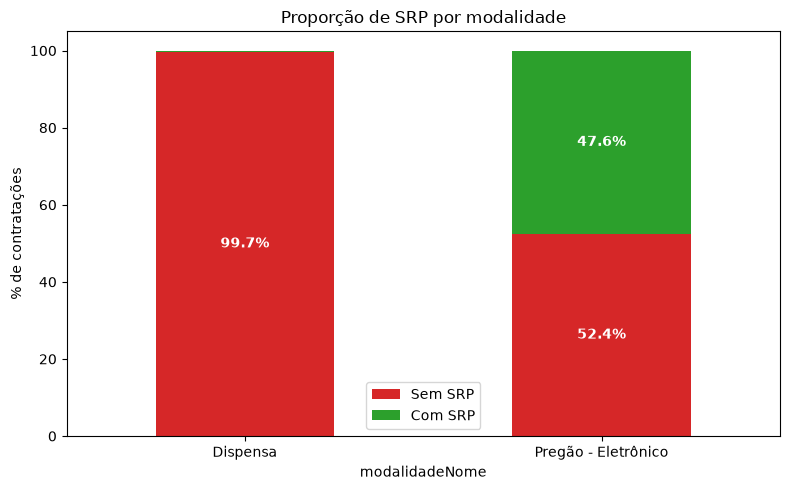

In [99]:
fig, ax = plt.subplots()

proporcao1.plot(kind='bar', stacked=True, color=['#d62728', '#2ca02c'], ax=ax)

# Adiciona o texto de porcentagem em cada segmento da barra
for i, modalidade in enumerate(proporcao1.index):
    acumulado = 0
    for coluna in proporcao1.columns:
        valor = proporcao1.loc[modalidade, coluna]
        if valor > 3:  # só mostra o texto se o segmento for grande o suficiente pra caber
            ax.text(
                i, acumulado + valor / 2,          # posição: meio do segmento
                f'{valor:.1f}%',                    # texto formatado com 1 casa decimal
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white'
            )
        acumulado += valor

plt.ylabel('% de contratações')
plt.title('Proporção de SRP por modalidade')
plt.legend(['Sem SRP', 'Com SRP'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('grafico1_srp_por_modalidade.png', dpi=150)
plt.show()

Os dados mostram uma diferença expressiva no uso do SRP entre as modalidades analisadas. Na Dispensa, o instrumento é praticamente inexistente, presente em apenas 0,26% das contratações (347 de 133.939). Já no Pregão-Eletrônico, quase metade das contratações (47,56%) utiliza o SRP. Essa disparidade sugere que a modalidade de contratação é um fator determinante na adoção do SRP, o que é coerente com a natureza do instrumento: por envolver registro de preços para consumo futuro por meio de disputa competitiva, o SRP se aplica naturalmente a processos licitatórios como o Pregão, sendo excepcional em contratações diretas como a Dispensa.

# Pergunta 2 - comparar se contratações com SRP têm valores diferentes das sem SRP.

In [100]:
com_srp_est = df_nulos[df_nulos['srp'] == True]['valorTotalEstimado'].dropna()
sem_srp_est = df_nulos[df_nulos['srp'] == False]['valorTotalEstimado'].dropna()

print("Mediana COM SRP (estimado):", com_srp_est.median())
print("Mediana SEM SRP (estimado):", sem_srp_est.median())

Mediana COM SRP (estimado): 433199.2
Mediana SEM SRP (estimado): 22500.0


In [101]:
com_srp_hom = df[df['srp'] == True]['valorTotalHomologado']
sem_srp_hom = df[df['srp'] == False]['valorTotalHomologado']

print("Mediana COM SRP (homologado):", com_srp_hom.median())
print("Mediana SEM SRP (homologado):", sem_srp_hom.median())

Mediana COM SRP (homologado): 290690.07999999996
Mediana SEM SRP (homologado): 19201.21


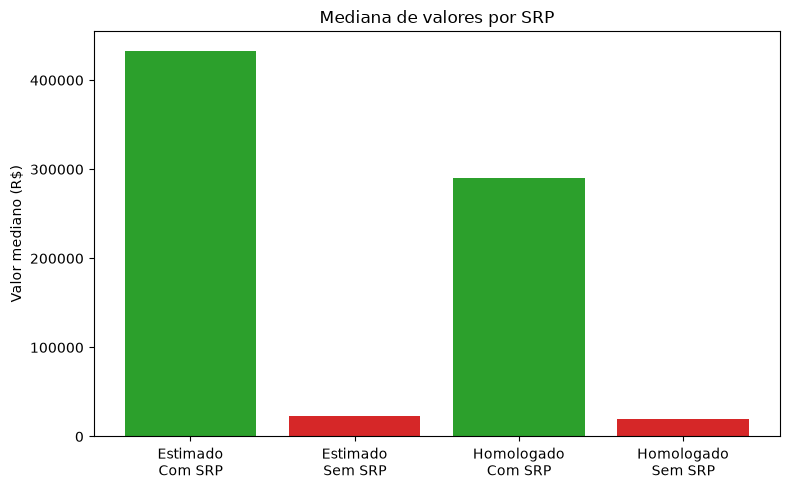

In [103]:
medianas = {
    'Estimado\nCom SRP': com_srp_est.median(),
    'Estimado\nSem SRP': sem_srp_est.median(),
    'Homologado\nCom SRP': com_srp_hom.median(),
    'Homologado\nSem SRP': sem_srp_hom.median(),
}

fig, ax = plt.subplots()
ax.bar(medianas.keys(), medianas.values(), color=['#2ca02c', '#d62728', '#2ca02c', '#d62728'])
ax.set_ylabel('Valor mediano (R$)')
ax.set_title('Mediana de valores por SRP')
plt.tight_layout()
plt.savefig('grafico2_medianas.png', dpi=150)
plt.show()

Contratações com SRP apresentam valores estimados e homologados consideravelmente maiores que as sem SRP (mediana de R$433.199 vs R$22.500 no valor estimado). Parte expressiva dessa diferença, no entanto, está associada à modalidade: ao restringir a comparação apenas ao Pregão-Eletrônico, o gap diminui bastante, mas permanece relevante (R$437.831 vs R$192.679). Isso indica que contratações via SRP tendem a envolver volumes maiores, mesmo dentro da mesma modalidade — plausivelmente porque as Atas de Registro de Preços costumam agregar demandas de múltiplas unidades ao longo de um período mais longo. Observou-se também que contratações com SRP apresentam maior taxa de deságio em relação ao valor estimado (33,3% vs 26,7%, já controlando por modalidade), sugerindo maior competitividade entre fornecedores nesses processos, possivelmente atraídos pelo volume agregado maior. Por fim, a taxa de não-homologação foi ligeiramente menor entre as contratações com SRP (13,2% vs 15,7%), uma diferença discreta que aponta para uma taxa de sucesso processual um pouco superior nesses casos.

# Pergunta 3

In [108]:
volume_por_orgao = df_nulos.groupby('orgaoEntidadeRazaoSocial').size()
orgaos_relevantes = volume_por_orgao[volume_por_orgao >= 30].index
df_filtrado = df_nulos[df_nulos['orgaoEntidadeRazaoSocial'].isin(orgaos_relevantes)]

In [109]:
ranking = (
    df_filtrado.groupby('orgaoEntidadeRazaoSocial')['srp']
    .mean()
    .sort_values(ascending=False)
    .head(15) * 100
)
print(ranking)

orgaoEntidadeRazaoSocial
FUNDACAO DE EDUCACAO, TURISMO, ESPORTE E CULTURA DE BOA VISTA       100.000000
MUNICIPIO DE IRITUIA                                                100.000000
MUNICIPIO DE GOVERNADOR NEWTON BELLO                                100.000000
MUNICIPIO DE GOVERNADOR MANGABEIRA                                  100.000000
MUNICIPIO DE SAO DOMINGOS DO CAPIM                                  100.000000
MUNICIPIO DE BORDA DA MATA                                           99.000000
MUNICIPIO DE CURRAIS NOVOS                                           98.901099
MUNICIPIO DE SILVES                                                  98.701299
CONSORCIO PUBLICO INTERMUNICIPAL DE GESTAO DA AMUSEP - PROAMUSEP     97.674419
TRIBUNAL DE CONTAS DO ESTADO DO ACRE                                 97.435897
MUNICIPIO DE GIRAU DO PONCIANO                                       97.142857
MUNICIPIO DE PEIXE-BOI                                               96.774194
MUNICIPIO DE CACERES       

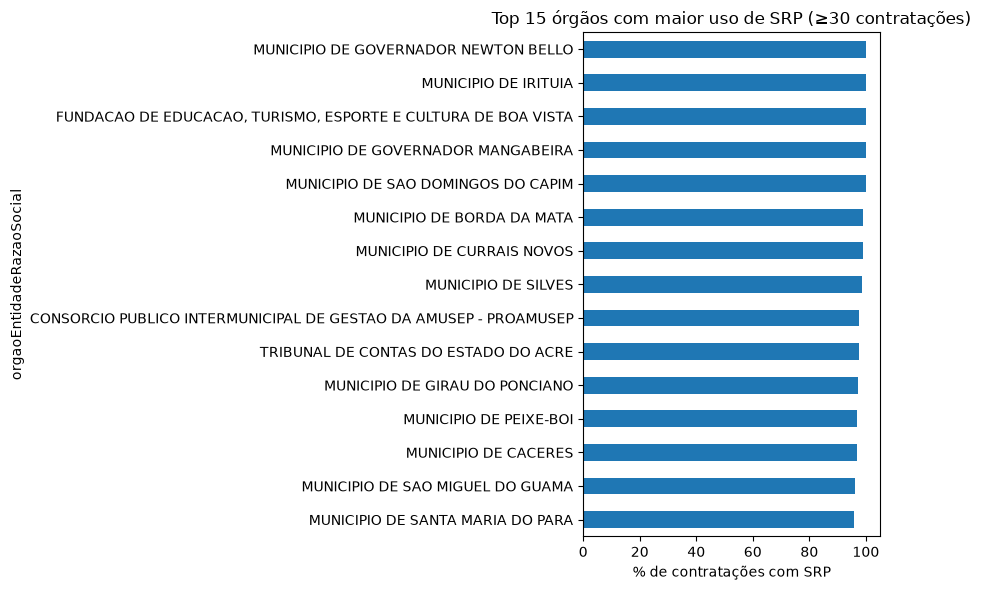

In [112]:
fig, ax = plt.subplots(figsize=(9, 6))
ranking.sort_values().plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_xlabel('% de contratações com SRP')
ax.set_title('Top 15 órgãos com maior uso de SRP (≥30 contratações)')
plt.tight_layout()
plt.savefig('grafico3_ranking_orgaos.png', dpi=150)
plt.show()

O ranking dos órgãos com maior proporção de uso de SRP (entre os com pelo menos 30 contratações no período) é dominado por municípios de pequeno porte, muitos deles com percentuais próximos a 100%. Isso sugere que, para esses municípios específicos, o SRP não é uma opção ocasional, mas praticamente o padrão adotado em suas contratações — possivelmente refletindo adesão a atas de registro de preços de âmbito regional ou estadual, uma prática comum entre municípios com estrutura administrativa mais enxuta. Vale notar que essa análise se concentra nos órgãos com volume mínimo de contratações no período coletado, o que garante alguma robustez ao achado, mas não permite generalizar esse padrão para todos os municípios do país.

# Conclusão geral
A análise indica que a modalidade de contratação é o fator mais associado ao uso do Sistema de Registro de Preços: o instrumento é praticamente exclusivo do Pregão-Eletrônico e residual na Dispensa. Contratações com SRP tendem a envolver valores mais altos e maior economia em relação ao estimado (deságio), mesmo quando se compara apenas dentro da mesma modalidade — o que sugere que o SRP está associado a processos de maior volume e competitividade, não apenas a uma diferença explicada pelo tipo de licitação. No nível dos órgãos, observa-se grande heterogeneidade: municípios específicos concentram uso quase universal do SRP, enquanto a maioria das contratações segue padrões mais próximos da média geral. Em conjunto, esses achados sugerem que o SRP é adotado de forma seletiva e concentrada — vinculado a determinados tipos de processo licitatório e a certos perfis de órgão — mais do que distribuído de forma homogênea pelo cenário de contratações públicas brasileiro.